# TSP - Travelling Salesman Problem
**Grupo 3 - Inteligencia Artificial USFQ**

Integrantes: Lucy Barreno, Ana Haro, Darwin Simba, Jhon Del Castillo

## ¿Qué es el TSP?

El **Problema del Vendedor Viajante (TSP)** consiste en encontrar la ruta más corta posible que:
- Visite cada ciudad **exactamente una vez**
- Regrese a la ciudad de origen formando un **ciclo cerrado**

Es un problema NP-difícil: con N ciudades existen **(N-1)!/2** rutas posibles. Con 20 ciudades eso equivale a más de **60 billones** de combinaciones, por lo que no es viable revisarlas todas. Se usan heurísticas para encontrar soluciones cercanas al óptimo.

### Representación del problema
El TSP se representa como un **grafo completo ponderado**:
- Cada ciudad es un **nodo**
- Cada conexión entre dos ciudades es una **arista**
- El **peso** de cada arista es la distancia entre las dos ciudades

## Algoritmo: Vecino más Cercano + 2-opt

Para más ciudades, el algoritmo exacto (Held-Karp) crece muy rápido. Esta heurística:
1. Construye una ruta inicial con **Vecino más Cercano**: desde la ciudad inicial, siempre va a la ciudad no visitada más cercana.
2. Mejora la ruta con **intercambios 2-opt**: busca pares de aristas que al invertirse reduzcan el costo total.

No garantiza óptimo global, pero suele dar rutas muy buenas en tiempos bajos.

Costo inicial (vecino mas cercano): 460.51
Costo mejorado (2-opt):             353.55
Mejora:                             23.2%


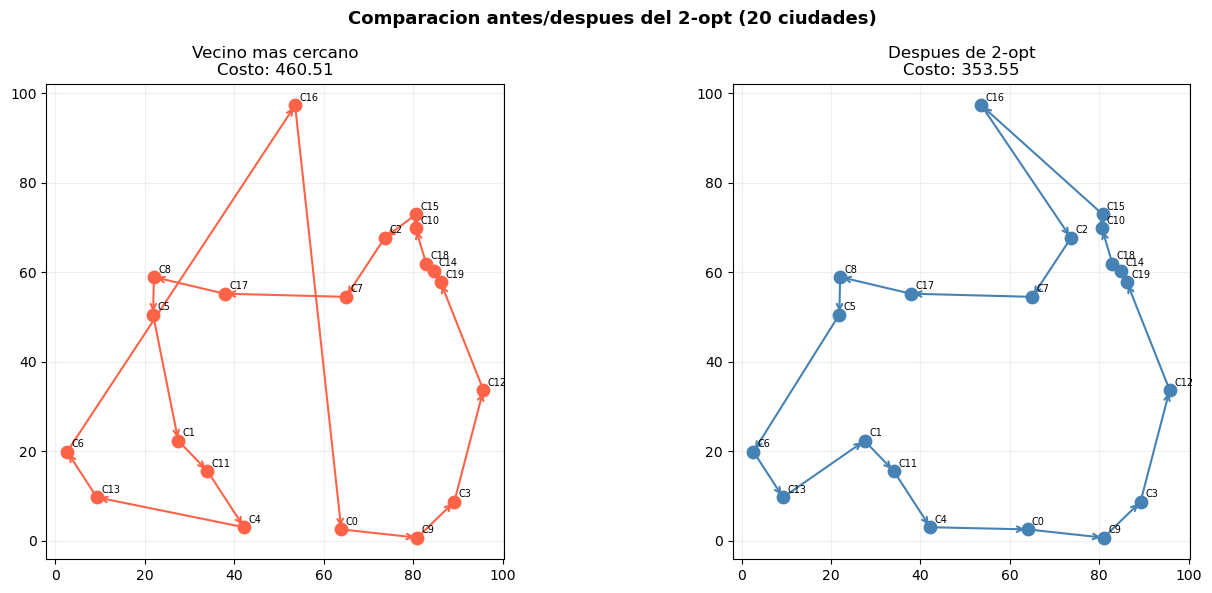

In [1]:
import math
import random
import matplotlib.pyplot as plt


def construir_matriz_distancias(coords):
    n = len(coords)
    dist = [[0.0] * n for _ in range(n)]
    for i in range(n):
        xi, yi = coords[i]
        for j in range(i + 1, n):
            xj, yj = coords[j]
            d = math.hypot(xi - xj, yi - yj)
            dist[i][j] = d
            dist[j][i] = d
    return dist


def costo_ruta(route, dist):
    return sum(dist[route[i]][route[i + 1]] for i in range(len(route) - 1))


def vecino_mas_cercano(dist, start=0):
    n = len(dist)
    no_visitadas = set(range(n))
    no_visitadas.remove(start)
    ruta = [start]
    actual = start
    while no_visitadas:
        siguiente = min(no_visitadas, key=lambda j: dist[actual][j])
        ruta.append(siguiente)
        no_visitadas.remove(siguiente)
        actual = siguiente
    ruta.append(start)
    return ruta


def dos_opt(route, dist):
    mejor = route[:]
    mejor_costo = costo_ruta(mejor, dist)
    n = len(mejor) - 1
    improved = True

    while improved:
        improved = False
        for i in range(n - 1):
            for j in range(i + 2, n):
                nueva = mejor[:i+1] + list(reversed(mejor[i+1:j+1])) + mejor[j+1:]
                nuevo_costo = costo_ruta(nueva, dist)
                if nuevo_costo < mejor_costo - 1e-10:
                    mejor = nueva
                    mejor_costo = nuevo_costo
                    improved = True
    return mejor, mejor_costo


def graficar_ruta_heuristica(coords, ruta_antes, ruta_despues, ciudades, dist):
    xs = [p[0] for p in coords]
    ys = [p[1] for p in coords]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, ruta, titulo, color in zip(
        axes,
        [ruta_antes, ruta_despues],
        [f"Vecino mas cercano\nCosto: {costo_ruta(ruta_antes, dist):.2f}",
         f"Despues de 2-opt\nCosto: {costo_ruta(ruta_despues, dist):.2f}"],
        ["tomato", "steelblue"]
    ):
        ax.set_title(titulo, fontsize=12)
        for i in range(len(ruta) - 1):
            a, b = ruta[i], ruta[i+1]
            ax.annotate("", xy=(xs[b], ys[b]), xytext=(xs[a], ys[a]),
                        arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
        ax.scatter(xs, ys, s=80, zorder=3, color=color)
        for i, nombre in enumerate(ciudades):
            ax.text(xs[i] + 1, ys[i] + 1, nombre, fontsize=7)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.2)

    plt.suptitle("Comparacion antes/despues del 2-opt (20 ciudades)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Datos: 20 ciudades aleatorias reproducibles
random.seed(42)
n_ciudades = 20
ciudades = [f"C{i}" for i in range(n_ciudades)]
coords = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(n_ciudades)]
dist = construir_matriz_distancias(coords)

ruta_inicial = vecino_mas_cercano(dist, start=0)
costo_inicial = costo_ruta(ruta_inicial, dist)

ruta_mejor, costo_mejor = dos_opt(ruta_inicial, dist)

print(f"Costo inicial (vecino mas cercano): {costo_inicial:.2f}")
print(f"Costo mejorado (2-opt):             {costo_mejor:.2f}")
print(f"Mejora:                             {(1 - costo_mejor/costo_inicial)*100:.1f}%")

graficar_ruta_heuristica(coords, ruta_inicial, ruta_mejor, ciudades, dist)

## Visualización 2: Mapa de Calor de Distancias

El mapa de calor muestra la **matriz de distancias** entre todas las ciudades. Los colores más claros indican ciudades más cercanas entre sí, y los más oscuros indican mayor distancia. La diagonal es siempre cero (distancia de una ciudad a sí misma).

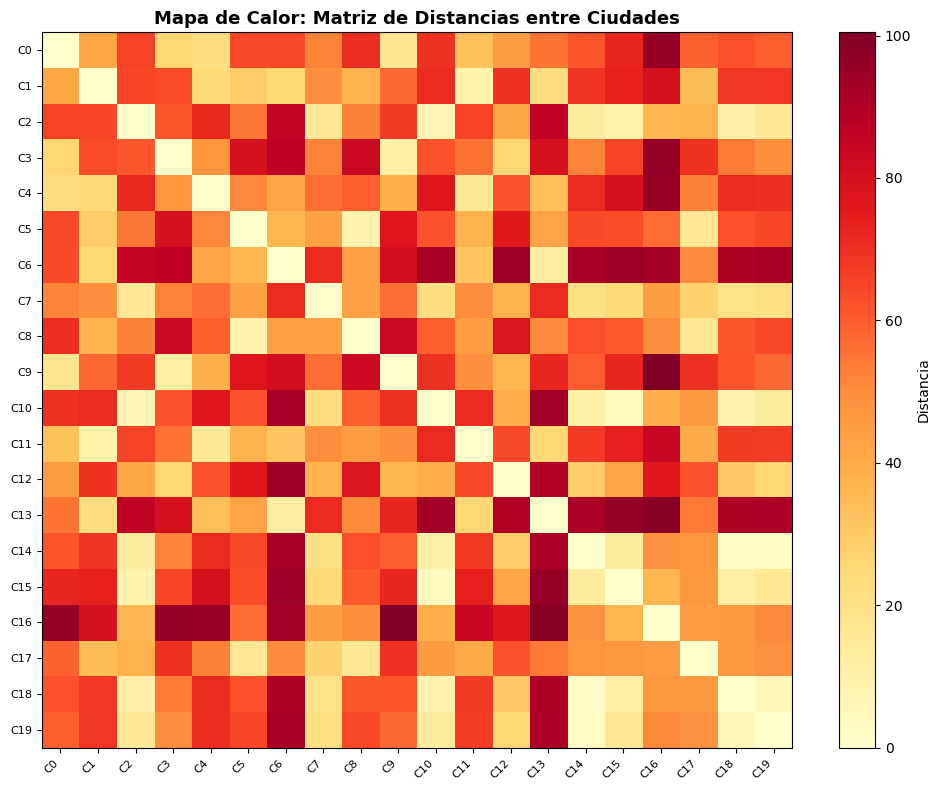

Distancia promedio entre ciudades: 52.84
Distancia maxima: 100.45
Distancia minima (no cero): 2.34


In [2]:
import numpy as np

# Mapa de calor de la matriz de distancias
matriz = np.array(dist)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Distancia')

ax.set_xticks(range(n_ciudades))
ax.set_yticks(range(n_ciudades))
ax.set_xticklabels(ciudades, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ciudades, fontsize=8)

ax.set_title('Mapa de Calor: Matriz de Distancias entre Ciudades', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Distancia promedio entre ciudades: {matriz[matriz > 0].mean():.2f}")
print(f"Distancia maxima: {matriz.max():.2f}")
print(f"Distancia minima (no cero): {matriz[matriz > 0].min():.2f}")

## Visualización 3: Grafo de la Ruta Óptima

Se muestra la ruta final obtenida después del 2-opt como un **grafo**, resaltando el orden de visita de cada ciudad y el costo de cada tramo.

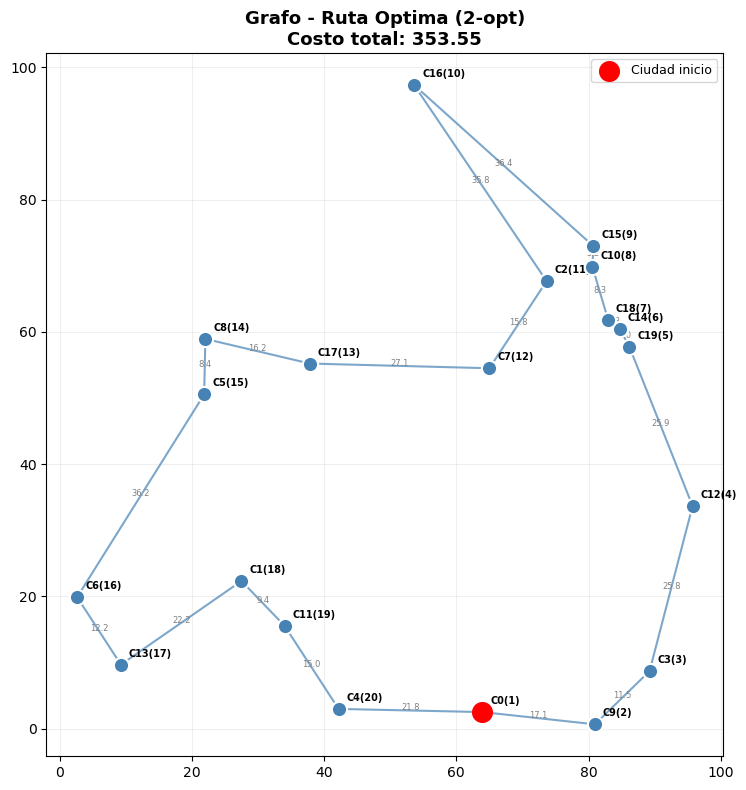

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))

xs = [p[0] for p in coords]
ys = [p[1] for p in coords]

# Dibujar todas las conexiones de la ruta óptima
for i in range(len(ruta_mejor) - 1):
    a, b = ruta_mejor[i], ruta_mejor[i + 1]
    ax.plot([xs[a], xs[b]], [ys[a], ys[b]], 'steelblue', lw=1.5, alpha=0.7)
    # Etiqueta del costo del tramo
    mx, my = (xs[a] + xs[b]) / 2, (ys[a] + ys[b]) / 2
    ax.text(mx, my, f"{dist[a][b]:.1f}", fontsize=6, color='gray', ha='center')

# Nodos
ax.scatter(xs, ys, s=120, zorder=5, color='steelblue', edgecolors='white', linewidths=1.5)

# Etiquetas de ciudades con orden de visita
for orden, idx in enumerate(ruta_mejor[:-1]):
    ax.text(xs[idx] + 1.2, ys[idx] + 1.2, f"{ciudades[idx]}({orden+1})", fontsize=7, fontweight='bold')

# Resaltar ciudad de inicio
inicio = ruta_mejor[0]
ax.scatter([xs[inicio]], [ys[inicio]], s=200, zorder=6, color='red', label='Ciudad inicio')

ax.set_title(f'Grafo - Ruta Optima (2-opt)\nCosto total: {costo_mejor:.2f}', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

## Conclusiones

### Sobre el problema
El TSP es un problema de optimización combinatoria con una complejidad factorial. Con 20 ciudades existen más de 60 billones de rutas posibles, lo que hace computacionalmente inviable una búsqueda exhaustiva. La representación más natural del problema es un **grafo completo ponderado**, donde cada nodo es una ciudad y cada arista tiene como peso la distancia entre dos ciudades.

### Sobre el algoritmo utilizado
La combinación **Vecino más Cercano + 2-opt** demostró ser eficiente:
- El Vecino más Cercano construyó rápidamente una ruta inicial razonable (costo: 460.51)
- El 2-opt mejoró esa ruta en un **23.2%** (costo final: 353.55) eliminando cruces innecesarios entre aristas
- El tiempo de ejecución fue muy bajo comparado con un algoritmo exacto

### Sobre la dificultad
- La principal dificultad del TSP es que **no existe un algoritmo eficiente que garantice la solución óptima** para un número grande de ciudades
- La representación visual mediante grafos y mapas de calor facilita la comprensión intuitiva del problema
- Las heurísticas como 2-opt ofrecen un buen balance entre calidad de la solución y tiempo de cómputo

### Aplicaciones reales
El TSP tiene aplicaciones directas en logística y delivery (optimización de rutas de reparto), diseño de circuitos electrónicos, planificación de rutas de drones y robótica.